<a href="https://colab.research.google.com/github/kartikeyabekkari/HyperRealisticNisqSimulation/blob/main/Hyper_Realistic_NISQ_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Imports



In [ ]:
!pip install --upgrade --force-reinstall cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import warnings
warnings.filterwarnings("ignore")


try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")


import matplotlib.pyplot as plt
import cirq_web
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!




---


#Parameters





In [19]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
deg = np.radians

---
#Divider
---

In [26]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
#================= Parameters =================

number_of_qubits_in_the_circuit = 2
number_of_runs = 4000
base_noise = 0.00036       # background error rate (idle qubits), decimal
high_noise = 0.0014        # elevated error rate for qubits under a gate this moment
distance_between_qubits = 2  # micrometers
amplitude_damp_chance = 0.0001

#================= Build Circuit =================
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([
    cirq.H(qubits[0]),
    cirq.CNOT(qubits[0], qubits[1]),
    cirq.measure(*qubits, key='result'),
])

print(f"Your Circuit:\n\n{base_circuit}\n")

Your Circuit:

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────



---
#Functions
---

In [39]:
LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)
def build_shot_circuit(original_circuit, all_qubits):
    circuit = cirq.Circuit()

    for moment in original_circuit:
        circuit.append(moment)

        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops = []
        depolarize_ops = []
        flipped_qubit_indices = []

        for q_idx, q in enumerate(all_qubits):
            error_rate = high_noise if q in active_loud_qubits else base_noise
            bit_flip_ops.append(cirq.bit_flip(p=error_rate)(q))
            depolarize_ops.append(cirq.depolarize(p=error_rate)(q))
            if np.random.rand() < error_rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(amplitude_damp_chance)(q) for q in all_qubits))

        # --- Crosstalk made with the flip idx above ---
        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0  # this qubit already flipped, therefore treat as certain
            elif flipped_qubit_indices:
                distance = [
                    abs(q_idx - flipped_idx) * distance_between_qubits for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distance), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))  # clamp to a valid probability
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit
# ================= Simulate + collect results =================
total_counts = Counter()


def simulate(circuit, type_of_noise=None):
    #Runs circuit once (1 shot) and adds the result into total_counts
    sim = cirq.Simulator()
    result = sim.run(circuit)
    total_counts.update(result.histogram(key='result'))


def graph(num_qubits, num_runs):
    # Creates bar chart
    print("\n--- SIMULATION RESULTS ---\n")

    total_possible_states = 2 ** num_qubits
    labels, values = [], []
    for outcome in range(total_possible_states):
        binary_string = format(outcome, f"0{num_qubits}b")
        labels.append(binary_string)
        actual_count = total_counts.get(outcome, 0)
        values.append(actual_count)
        print(f"State |{binary_string}⟩: {actual_count} times = {(actual_count / num_runs) * 100:.2f}%")

    plt.figure(figsize=(1 + 2 * num_qubits, 6))
    plt.bar(labels, values, color="lightblue", edgecolor="lightblue")
    plt.title(f"Combined Total For {num_runs} Procedural Runs")
    plt.xlabel("Quantum States")
    plt.ylabel("Total Count")
    plt.xticks(rotation=315, fontsize=8)
    plt.grid(axis="y", linestyle="--", alpha=0.85)
    plt.tight_layout()
    plt.show()


def run_NISQ_simulation(circuit_template, all_qubits, num_runs):
    # defines how to run
    total_counts.clear()
    print(f'Circuit:\n{base_circuit}')
    for _ in range(num_runs):
        shot_circuit = build_shot_circuit(circuit_template, all_qubits)
        #print(shot_circuit)
        simulate(shot_circuit)
    graph(len(all_qubits), num_runs)

# Run the circuit


Circuit:
0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────

--- SIMULATION RESULTS ---

State |00⟩: 1997 times = 49.93%
State |01⟩: 10 times = 0.25%
State |10⟩: 16 times = 0.40%
State |11⟩: 1977 times = 49.43%


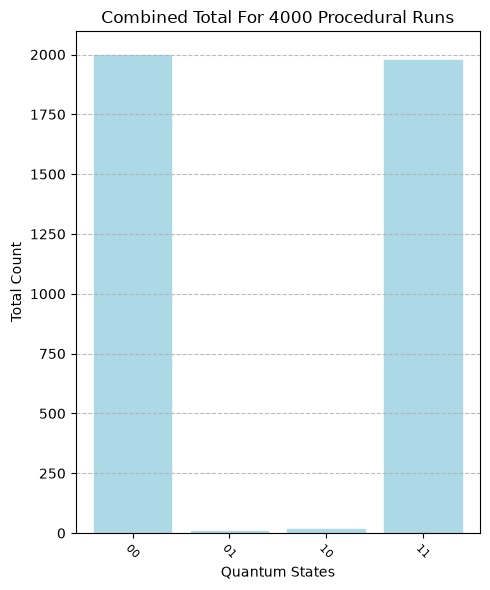

In [40]:
run_NISQ_simulation(base_circuit, qubits, number_of_runs)

#
---

#Divider 2


In [33]:


from __future__ import annotations

from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    high_noise: float          # error rate on actively-driven qubits
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


# "Low error percentage" baseline -- bulk of the training data.
LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    high_noise=0.0002,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

# Higher, more realistic error rates -- mimics an actual NISQ device.
# Placeholder... scale-up until calibrated against real hardware data.
REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.002,
    high_noise=0.1,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Noise + crosstalk model (same as nisq_corrected.py) =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        circuit.append(moment)
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops, depolarize_ops, flipped_qubit_indices = [], [], []
        for q_idx, q in enumerate(all_qubits):
            rate = config.high_noise if q in active_loud_qubits else config.base_noise
            bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, high_noise, amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.high_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements['result'][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements['result'][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Per-qubit accuracy, useful for seeing which qubits are hardest to correct."""
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    """Converts an (N, num_qubits) array of 0/1 rows into an (N,) array of integer state indices."""
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    """Inverse of bits_to_state_indices: turns integer class labels back into 0/1 bit rows."""
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def plot_before_after_histograms(y_ideal: np.ndarray, y_noisy: np.ndarray, y_corrected: np.ndarray, num_qubits: int):
    """
    Side-by-side histograms over every computational basis state (|0000>
    ... |1111>), comparing the ideal distribution against the raw noisy
    results (before correction) and the ML-corrected results (after
    correction). Same y-axis scale on both so the improvement is visually
    comparable.
    """
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    ideal_counts = np.bincount(bits_to_state_indices(y_ideal), minlength=num_states)
    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    y_max = max(ideal_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= Main training + evaluation pipeline =================
def main():
    number_of_qubits = 3
    qubits = cirq.LineQubit.range(number_of_qubits)
    base_circuit = cirq.Circuit([
        cirq.H(qubits[0]),
        cirq.CNOT(qubits[0], qubits[1]),
        cirq.measure(*qubits, key='result'),
    ])

    ideal_sim = cirq.Simulator()

    print("Generating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=8000, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    # Training set: mostly low-noise (the "low error percentage" data),
    # with a smaller slice of real-world-noise data mixed in so the model
    # has at least seen the harder error regime it'll be evaluated on.
    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    X_train, X_holdout, y_train, y_holdout = train_test_split(X_train, y_train, test_size=0.15, random_state=0)

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    y_train_labels = bits_to_state_indices(y_train)
    model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0)
    model.fit(X_train, y_train_labels)

    # --- Evaluate on the held-out real-world test set ---
    noisy_bits_test = X_real_test[:, -number_of_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, number_of_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points\n")
    for i in range(number_of_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # --- Plots ---
    plot_before_after_histograms(y_real_test, noisy_bits_test, corrected_bits_test, number_of_qubits)

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy", "ML-corrected"], [raw_acc * 100, corrected_acc * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(evaluated on real-world-noise test set)")
    plt.ylim(0, 100)
    for i, v in enumerate([raw_acc * 100, corrected_acc * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 7650  (holdout: 1350, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       37.30%
Model-corrected bitstring accuracy: 48.80%
Improvement:                        +11.50 percentage points

  qubit 0: raw=49.80%  corrected=48.80%
  qubit 1: raw=49.70%  corrected=48.80%
  qubit 2: raw=96.10%  corrected=100.00%


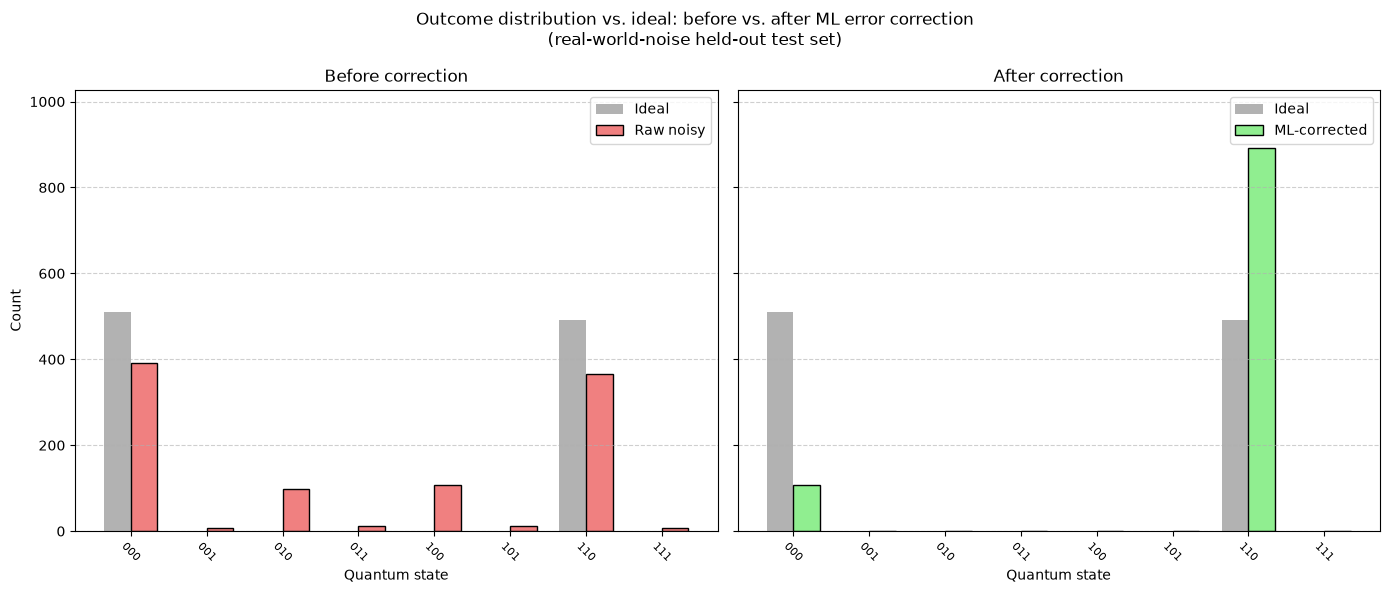

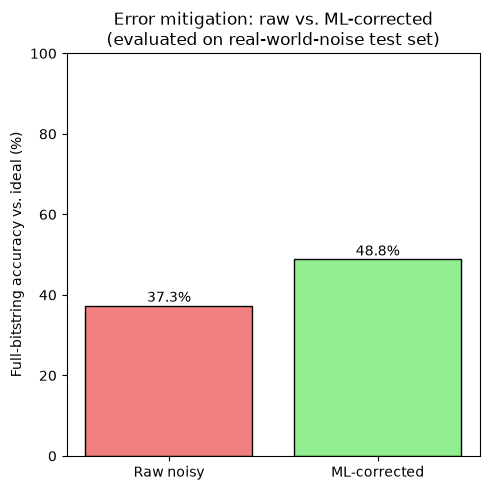

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 7650  (holdout: 1350, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       38.00%
Model-corrected bitstring accuracy: 52.00%
Improvement:                        +14.00 percentage points

  qubit 0: raw=52.00%  corrected=52.00%
  qubit 1: raw=51.00%  corrected=52.00%
  qubit 2: raw=95.60%  corrected=100.00%


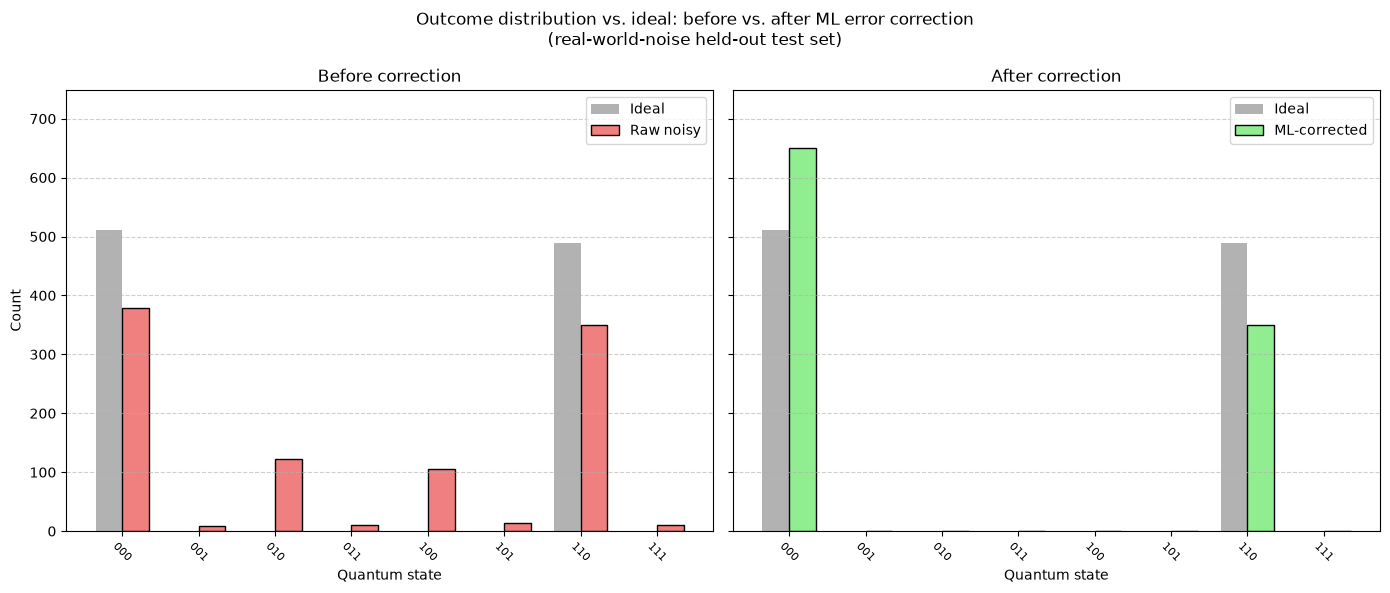

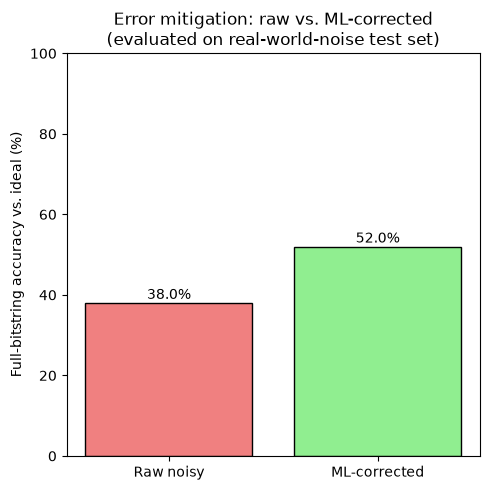

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 7650  (holdout: 1350, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       36.00%
Model-corrected bitstring accuracy: 48.70%
Improvement:                        +12.70 percentage points

  qubit 0: raw=48.50%  corrected=48.70%
  qubit 1: raw=49.80%  corrected=48.70%
  qubit 2: raw=95.20%  corrected=100.00%


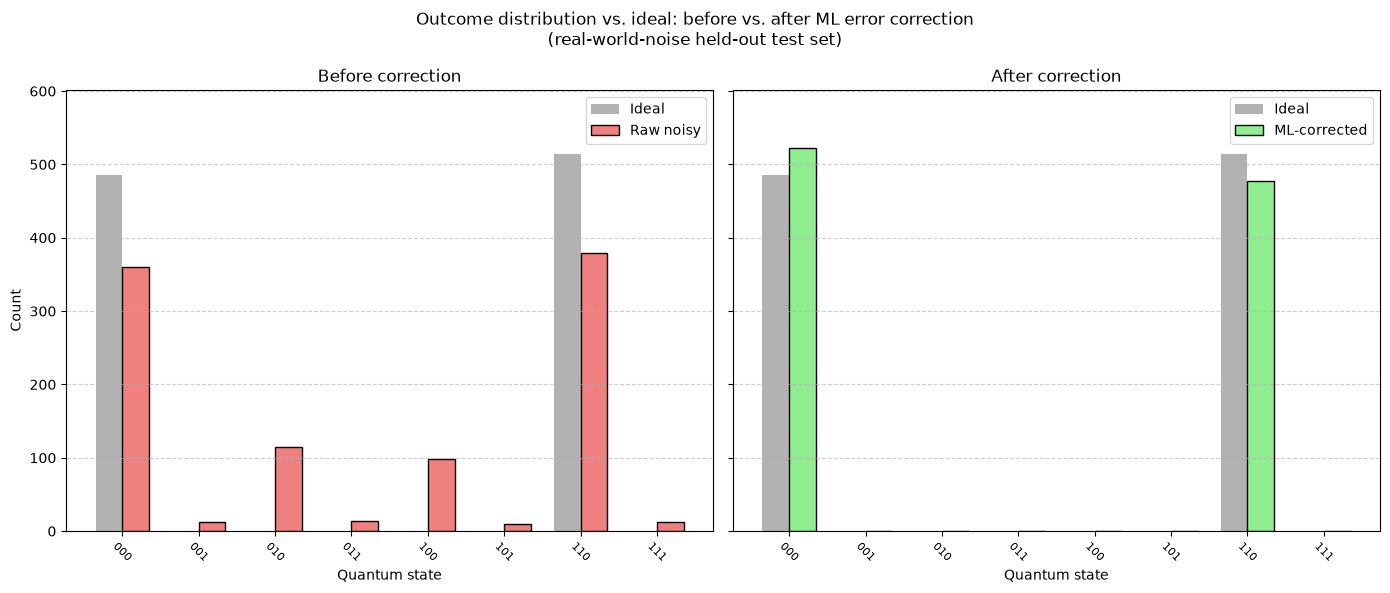

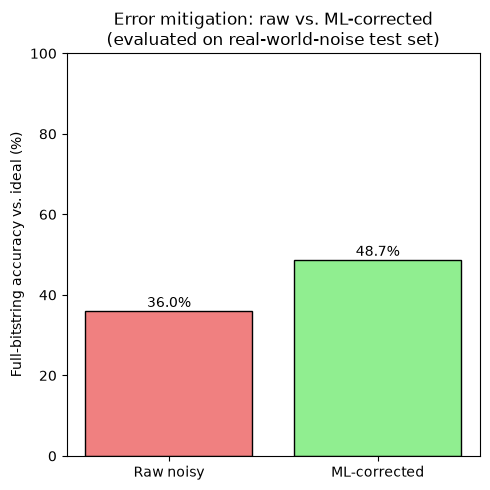

Generating LOW-noise training data (clean baseline)...


KeyboardInterrupt: 

In [35]:
for num in range(4):
  main()